# Set-up

## Load libraries

In [2]:
#Set directory
setwd(here())
#Install and load libraires
# invisible(source("./src/install_librairies.r"))
# install_packages(directory)
invisible(source("./src/load_librairies.r"))
# Load functions
invisible(source("./src/help_functions.r"))


Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'reshape2'


L'objet suivant est masqué depuis 'package:tidyr':

    smiths



Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine



Attachement du package : 'Matrix'


Les objets suivants sont masqués depuis '

## Load and clean dataset

In [3]:
#Load dataset
ca125 <- read.csv("./data/MAOV_ca125_all.csv", sep=";")
ca125 <- ca125%>%mutate(id=paste(trialid,"_",patid)) 
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)


n_patients,n_trials,n_measures
<int>,<int>,<int>
8219,13,102809


In [4]:
#Clean dataset
#check time between first surgery and first measure
Sys.setlocale("LC_TIME", "C")
ca125$delay_surg_trt<-(as.Date(toupper(ca125$dotrt_begin), format = "%d%b%Y")-as.Date(toupper(ca125$dosurg1), format = "%d%b%Y"))
#delete patients with delay <7
ca125<- ca125[!ca125$id %in% unique(ca125$id[ca125$delay_surg_trt < 7 & !is.na(ca125$delay_surg_trt)]),]

[1] "C"

In [5]:
# Clean first progression column
ca125 <- ca125 %>%
  mutate(
    dor = as.Date(toupper(dor), format = "%d%b%Y"),
    dofirst_prog = as.Date(toupper(dofirst_prog), format = "%d%b%Y"),
    dofirst_prog = if_else(
      is.na(dofirst_prog) & !is.na(dor),
      dor + pfs_time_m * 30.4375,
      dofirst_prog
    )
  )
ca125 <- ca125 %>%
  mutate(
    dotrt_begin = as.Date(toupper(dotrt_begin), format = "%d%b%Y"),
    donext_trt = as.Date(toupper(donext_trt), format = "%d%b%Y"),
    do_CA125 = as.Date(toupper(do_CA125), format = "%d%b%Y")
  )

In [6]:
#delete measures after progression 
ca125<-ca125 %>%
  filter( (trialid != "MRC-ICON7" & do_CA125 <= dofirst_prog) |
        (trialid == "MRC-ICON7" & time_ca125<=pfs_time_m * 30.4375))

In [ ]:
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

In [7]:
#Create variables
ca125$trt_bin<- if_else(ca125$trt=="Standard regimen", 0,1)
ca125["os_time_d"]<-ca125$os_time_m*30.4375
ca125["pfs_time_d"]<-ca125$pfs_time_m*30.4375
ca125["os_statut"]<-factor(ifelse(ca125$os_status=='Yes', 1, 0), levels=c(0,1))
ca125["pfs_statut"]<-factor(ifelse(ca125$PFS_status=='Yes', 1, 0), levels=c(0,1))
#restrict data                             
colonnes<-c("trialid","patid","id",'trt','dor','CA125_mes','do_CA125','id_temp','dotrt_begin', "donext_trt",'dotrt_end',"time_ca125",'os_status','OS_time','PFS_status','PFS_time',"nb_mesures",
"ca125_base",'Visit','pfs_time_m',"pfs_time_d",'os_time_m',"os_time_d",'group','country','maov_group','dob','age','figo','figo4c',"trt_bin","os_statut","pfs_statut")
ca125_all_6 <- ca125[colonnes]%>%
  filter(time_ca125 <= 188) %>%
  group_by(id) %>%
  filter(n() > 1) %>%
  ungroup()
ca125_all_6["id_num"]<- as.numeric(as.factor(ca125_all_6$id))
ca125_all_6["trialid_num"]<- as.numeric(as.factor(ca125_all_6$trialid))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [ ]:
ca125_all_6 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

# Summarise data

## Main characteristics

In [ ]:
ca125_all_6 %>%
  group_by(trialid) %>%
  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),

     # percentage deaths
    mean_baseline = round(mean(ca125_base, na.rm = TRUE),2),
    
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

In [ ]:
ca125_all_6 %>%  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

## Evolution of CA-125

In [ ]:
# set.seed(123)
# Select 20 random patients
selected_ids <- ca125_all_6 %>%
  distinct(id) %>%
  sample_n(20) %>%
  pull(id)
subset_data <- ca125_all_6[ca125_all_6$time_ca125<=90,] %>%
  filter(patid %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time for 20 Random Patients",
    x = "Time (measurement)", 
    y = "Log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


In [ ]:
# Compute trends per patient over 90 days of observation
df_trends_180 <- ca125_all_6%>%
  group_by(id) %>%
  summarise(trend_cat = trend(log_ca125, time_ca125), .groups = "drop")

# Join back to the original dataset
df_180 <- ca125_all_6 %>%
  left_join(df_trends_180, by = "id")
table(df_180$trend_cat)


In [ ]:
options(repr.plot.width = 14, repr.plot.height = 6)
selected_ids <- df_180[df_180$trend_cat=="decreasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (decreasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

In [ ]:
selected_ids <- df_180[df_180$trend_cat=="increasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (increasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

In [ ]:
ca125_all_6 %>%
  
  # keep repeated measures if you want ALL CA125 values
  group_by(trialid, trt) %>%
  
  summarise(
    
    n_measures = n(),
    n_patients = n_distinct(id),
    
    minca125 = min(CA125_mes, na.rm = TRUE),
    
    q1_ca125 = quantile(CA125_mes, 0.25, na.rm = TRUE),
    
    mean_ca125 = mean(CA125_mes, na.rm = TRUE),
    
    q3_ca125 = quantile(CA125_mes, 0.75, na.rm = TRUE),
    
    max_ca125 = max(CA125_mes, na.rm = TRUE),
        # percentage deaths
    pct_death = mean(os_statut == 1, na.rm = TRUE) * 100,
    # percentage progression
    pct_progression = mean(pfs_statut == 1, na.rm = TRUE) * 100,
    # median OS time
    median_os_time_d = median(os_time_d, na.rm = TRUE),
    # median PFS time
    median_pfs_time_d = median(pfs_time_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  
  arrange(trialid, trt)

# Joint modeling

## Specification

**Longitudinal model**
$
Y_i(t) = (\beta_0 +b_{0i})+ \sum_{k=1}^{3} (\beta_k+b_{ki}) \, ns_k(t)+ \sum_{k=1}^{3} \gamma_k \, ns_k(t)*T_i+ \varepsilon_i(t)
$

$
b_i \sim \mathcal{N}(0, D), \quad \varepsilon_i(t) \sim \mathcal{N}(0, \sigma^2)
$\
**Survival model**
$
h_i(t) = h_0(t)\exp(\alpha \, T_i)
$

$
h_0(t) = \sum_{m=1}^{M} \lambda_m B_m(t)
$

**Joint association structure**

$
h_i(t \mid b_i) = h_0(t)\exp(\alpha \, T_i + \eta^\top b_i)
$\
**Full likelihood**

$
L = \prod_{i=1}^N 
\int 
f(Y_i \mid b_i)\,
f(T_i, \delta_i \mid b_i)\,
f(b_i)\, db_i
$

**Longitudinal model details**

With splines :
- s trials
- $n_i$ patients in trial $i$, $n = \sum_{i=1}^{s} n_i$ the total number of patients
- $m_{ij}$ the number of measures for patient j in study i, $m_{i}=\sum_{j=1}^{n_i} m_{ij}$ the total number of observations in trial $i$, $N=\sum_{i=1}^{s} m_i=\sum_{i=1}^{s}\sum_{j=1}^{n_i} m_{ij}$ the total number of observations
- $y(t_{ijk})$ the $k^{th}$ value $k \in {1,...,m_{ij}}$ of biomarker CA-125 for patient $j$, $j \in {1,...,n_i}$, in study $i$, $i \in {1,...,s}$
- 
$$
T_{ij}=
\begin{cases} 
1 & \text{if patient $j$ in trial $i$ received the treatment} 
\\ 0 & \text{otherwise}
\end{cases}
$$

Mixed-effects model for varataion of $y$:
$
log[y(t_{ijk})]= f(t_{ijk}) +\epsilon_{ijk}
$, 
with:
- $ f(t)= (\theta_{1}+b_{1i}+b_{1ij}) + (\theta_{4}+b_{4ij})t+ \sum_{k=0}^1 (\theta_{k+2}+ b_{k+2,ij})B_{k+2}(t)+ (\theta_{5}+ b_{5,i})T_{ij}*t+ \sum_{k=0}^1 (\theta_{k+6}+ b_{k+6,i}) T_{ij}*B_{k+2}(t)$; $B_{k+2}(t) = d_{k} - d_2; d_k=\frac{(t-q_k(t))_{+}^3 - (t-q_3(t))_{+}^3}{q_k(t) - q_3(t)} \text{ , } k \in\ \{0,1\}$
- $x_+ = max (0, x)  $,
- $q_0(t), q_1(t), q_2(t) \text{ and } q_3(t)  \text{ are quantiles of t at 18\%, 22\%, 66\%, and 98\%} $
- $(b_{1i}, b_{5i},b_{6i},b_{7i})^\top \sim N(0, \phi)$, $\phi = \begin{pmatrix} \sigma_{1}^2 & \sigma_1\sigma_5 &\sigma_1\sigma_6 & \sigma_1\sigma_7\\ \sigma_1\sigma_5 & \sigma_{5}^2 & \sigma_5\sigma_6 & \sigma_5\sigma_7\\ \sigma_1\sigma_6 & \sigma_5\sigma_6 & \sigma_{6}^2& \sigma_6\sigma_7 \\ \sigma_1\sigma_7 & \sigma_5\sigma_7 & \sigma_6\sigma_7 & \sigma_{7}^2 \end{pmatrix}$  (random effect at study level)
- $ (b_{1ij},b_{4ij},b_{2ij}, b_{3ij})^t \sim N(0, D)$, $D = \begin{pmatrix} \sigma_{b1}^2 & \sigma_{b1b4} & \sigma_{b1b2} & \sigma_{b1b3} \\ \sigma_{b1b4} & \sigma_{b4}^2 &  \sigma_{b2b4} & \sigma_{b3b4} \\ \sigma_{b1b2} & \sigma_{b2b4} &\sigma_{b2}^2 & \sigma_{b2b3} \\ \sigma_{b1b3} & \sigma_{b3b4} & \sigma_{b2b3} & \sigma_{b3}^2 \end{pmatrix}$(random effects at patient-level)
- $\epsilon_{ijk} \sim N(0, \sigma^2_\epsilon I_N)$


**Conditional BLUP for patient-level random effects**:

- $\theta=(\theta_1 \text{  } \theta_4 \text{  } \theta_2 \text{  } \theta_3 \text{  } \theta_5 \text{  } \theta_6 \text{  } \theta_7)^T$

Matricial form: $ y= X\theta + Z_sb_s + Z_{n}b_{n} + \epsilon$, with :
$
y =
\begin{pmatrix}
y(t_{111}) \\
y(t_{112}) \\
\vdots \\
y(t_{11 m_{11}}) \\
y(t_{121}) \\
\vdots \\
y(t_{1 n_1 m_{1m=n_1}}) \\
\vdots \\
y(t_{s n_s m_{sn_s}})
\end{pmatrix}
\in \mathbb{R}^{N},
\qquad
$,
$
X =
\begin{pmatrix}
1 & t_{111} & B_2(t_{111}) & B_3(t_{111}) & T_{11}*t_{111} & T_{11}*B_2(t_{111}) & T_{11}*B_3(t_{111}) \\
1 & t_{112} & B_2(t_{112}) & B_3(t_{112}) & T_{11}*t_{112} & T_{11}*B_2(t_{112}) & T_{11}*B_3(t_{112}) \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
1 & t_{11 m_{11}} & B_2(t_{11 m_{11}}) & B_3(t_{11 m_{11}}) & T_{11}*t_{11 m_{11}} & T_{11}*B_2(t_{11 m_{11}}) & T_{11}*B_3(t_{11 m_{11}}) \\
1 & t_{121} & B_2(t_{121}) & B_3(t_{121}) & T_{12}*t_{121} & T_{12}*B_2(t_{121}) & T_{12}*B_3(t_{121})\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & t_{s n_s m_{sn_s}} & B_2(t_{s n_s m_{sn_s}}) & B_3(t_{s n_s m_{sn_s}}) & T_{sn_s}*t_{t_{s n_s m_{sn_s}}} & T_{sn_s}*B_2(t_{t_{s n_s m_{sn_s}}}) & T_{sn_s}*B_3(t_{t_{s n_s m_{sn_s}}})
\end{pmatrix}
\in \mathbb{R}^{N \times 7}
$
- $b_s \sim N(0, \Phi)$, $\Phi = \mathrm{diag}(\phi,...,\phi) \in \mathbb{R}^{6s \times 6s}$ (study-level random intercept)
$$
b_s =
\begin{pmatrix}
b_{11} & b_{51} &  b_{61}& b_{71} \\
b_{12} & b_{52} &  b_{62}& b_{72}  \\
\vdots & \vdots & \vdots & \vdots \\
b_{1s} & b_{5s} & b_{6s} &  b_{7s}
\end{pmatrix}
\in \mathbb{R}^{s \times 4}
$$
- $b_{n} \sim N(0, \Delta)$ (patient-level random intercept+slope), $
\Delta = \mathrm{diag}(D,...,D) \in \mathbb{R}^{5n \times 5n}
$

$$
b_{n} =
\begin{pmatrix}
b_{1,11} \\
b_{4,11} \\
b_{2,11} \\
b_{3,11} \\
b_{1,12} \\
b_{4,12} \\
b_{2,12} \\
b_{3,12} \\
\vdots \\
b_{1,s n_s} \\
b_{4,s n_s} \\
b_{2,s n_s}\\
b_{3,s n_s}
\end{pmatrix}
\in \mathbb{R}^{4n},
\qquad
$$

- $\epsilon \sim N(0, \sigma^2_{\epsilon}I_N)$

$\boxed{Var(y)=V=Z_s \Phi Z_s^T + Z_{n}\Delta Z_{n}^T + \sigma^2_{\epsilon}I_N}$\
with:
- $ Z_s =\begin{pmatrix}\mathbf{Z}_{s_1} & 0 & \cdots & 0 \\0 & \mathbf{Z}_{s_2} & \cdots & 0 \\\vdots & \vdots & \ddots & \vdots \\0 & 0 & \cdots & \mathbf{Z}_{s_s}\end{pmatrix} \in \mathbb{R}^{N \times 6s}$
. For trial $i$, $ Z_{s_i} =\begin{pmatrix}1 & T_{i1}*t_{i11} & T_{i1}*B_2(t_{i11}) & T_{i1}*B_3(t_{i11})\\1 & T_{i1}*t_{i12} & T_{i1}*B_2(t_{i12}) & T_{i1}*B_3(t_{i12}) \\\vdots & \vdots & \vdots\\1 & T_{in_i}*t_{in_im_i} & T_{in_i}*B_2(t_{in_im_i}) & T_{in_i}*B_3(t_{in_im_i}) \end{pmatrix}\in \mathbb{R}^{m_{i} \times 4}$

For patient $(i,j)$,:

$
Z_{ij}=\begin{pmatrix}1 & t_{ij1} & B_2(t_{ij1}) & B_3(t_{ij1})\\1 & t_{ij2}&  B_2(t_{ij2}) & B_3(t_{ij2})\\\vdots & \vdots & \vdots\\1 & t_{ijm_{ij}}& B_2(t_{ijm_{ij}}) & B_3(t_{ijm_{ij}})\end{pmatrix}\in \mathbb{R}^{m_{ij} \times 4}$, 
$
Z_{n}=\begin{pmatrix}Z_{11} & 0 & \cdots & 0\\0 & Z_{12} & \cdots & 0\\\vdots & \vdots & \ddots & \vdots\\0 & 0 & \cdots & Z_{s n_s}\end{pmatrix} \in \mathbb{R}^{N \times 4n}
$

$$
\widehat{b}_{n} = \Delta Z_{n}^\top V^{-1}(y-X\hat{\theta})
$$
$
\begin{pmatrix}
\hat b_{1ij} \\
\hat b_{4ij} \\
\hat b_{2ij}\\
\hat b_{3ij}
\end{pmatrix}
=[\Delta]_{ij}\sum_{k=1}^{m_{ij}}\begin{pmatrix}1\\ t_{ijk} \\B_2(t_{ijk}) \\B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$


**BLUP for Study-Level Random Effect**\
$$
\widehat{b}_{s} = \Phi Z_s^\top V^{-1} (y-X\hat{\theta}) 
$$
$
\begin{pmatrix}
\hat b_{1i} \\
\hat b_{5i} \\
\hat b_{6i}\\
\hat b_{7j}
\end{pmatrix}
=[\Phi]_{i} \sum_{j=1}^{n_i} \sum_{k=1}^{m_{ij}}\begin{pmatrix}1 \\T_{ij}*t_{ijk} \\T_{ij}*B_2(t_{ijk}) \\T_{ij}*B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$



**Fixed Effects Estimate**\
Stack all data across studies:
$$
\hat{\beta} = (\mathbf{X}^\top \mathbf{V}^{-1} \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{V}^{-1} \mathbf{y}
$$

## Computation

In [ ]:
pak::pak("DenisRustand/INLAjoint")

In [ ]:
library(INLAjoint)
library(INLA)

In [ ]:
#Model input
ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
ca125_all_6_surv<-ca125_all_6[!duplicated(ca125_all_6$id),]
f1 <- function(x) predict(ns_basis, x)[,1]
f2 <- function(x) predict(ns_basis, x)[,2]
f3 <- function(x) predict(ns_basis, x)[,3]
ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
n_trials<- length(unique(ca125_all_6$trialid_num))

In [ ]:
#model setup
formLong <- log_ca125 ~ f1(time_ca125) + f2(time_ca125) + f3(time_ca125) + trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)+ (1 + f1(time_ca125) + f2(time_ca125)+ f3(time_ca125) |id_num)#+(trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)|trialid_num) #DR cette partie de la formule était ignorée
formSurv <- INLA::inla.surv(pfs_time_d, pfs_statut) ~ trt_bin + (trt_bin|trialid_num)
model_setup <- joint(
  formSurv  = list(formSurv),
  formLong  = list(formLong),
  dataSurv  = as.data.frame(ca125_all_6_surv),
  dataLong  = as.data.frame(ca125_all_6),
  id        = "id_num",
  timeVar   = "time_ca125",
  family    = "gaussian",
  basRisk   = "rw2", 
  NbasRisk = 50,
  assoc     = "SRE_ind",
  control   = list(int.strategy = "eb", verbose=TRUE),
  run=FALSE, 
)
formLong_trial <- log_ca125 ~ trt_bin + f1(time_ca125) + f2(time_ca125) + f3(time_ca125) + trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)+(1 + f1(time_ca125)+ f2(time_ca125)+ f3(time_ca125)|trialid_num)
model_setup_trial <- joint(
  formSurv  = list(formSurv),
  formLong  = list(formLong_trial),
  dataSurv  = as.data.frame(ca125_all_6_surv),
  dataLong  = as.data.frame(ca125_all_6),
  id        = "trialid_num",
  timeVar   = "time_ca125",
  family    = "gaussian",
  basRisk   = "rw2", 
  NbasRisk = 50,
  assoc     = "SRE_ind",
  corRE= FALSE, 
  control   = list(int.strategy = "eb", verbose=TRUE), 
  run=FALSE,
)


In [ ]:
# #Treatment * splines random effects id
# model_setup$.args$data$IDIntercept_S2 <- model_setup_trial$.args$data$IDIntercept_S1
# model_setup$.args$data$WIntercept_S2 <- model_setup_trial$.args$data$WIntercept_S1*model_setup_trial$.args$data$trt_bin_S1
# model_setup$.args$data$IDTrial0 <- model_setup_trial$.args$data$IDIntercept_L1
# model_setup$.args$data$IDTrial1 <- model_setup_trial$.args$data$IDf1time_ca125_L1
# model_setup$.args$data$IDTrial2 <- model_setup_trial$.args$data$IDf2time_ca125_L1
# model_setup$.args$data$IDTrial3 <- model_setup_trial$.args$data$IDf3time_ca125_L1

# # Treatment * splines random effects weights
# model_setup$.args$data$WTrial0 <- model_setup_trial$.args$data$WIntercept_L1
# model_setup$.args$data$WTrial1 <- model_setup_trial$.args$data$Wf1time_ca125_L1 * model_setup_trial$.args$data$trt_bin_L1
# model_setup$.args$data$WTrial2 <- model_setup_trial$.args$data$Wf2time_ca125_L1 * model_setup_trial$.args$data$trt_bin_L1
# model_setup$.args$data$WTrial3 <- model_setup_trial$.args$data$Wf3time_ca125_L1 * model_setup_trial$.args$data$trt_bin_L1

# # Share and scale the trial level random effects in survival
# model_setup$.args$data$IDTrial0_SRE <- model_setup_trial$.args$data$SRE_Intercept_L1_S1
# model_setup$.args$data$IDTrial1_SRE <- model_setup_trial$.args$data$SRE_f1time_ca125_L1_S1
# model_setup$.args$data$IDTrial2_SRE <- model_setup_trial$.args$data$SRE_f2time_ca125_L1_S1
# model_setup$.args$data$IDTrial3_SRE <- model_setup_trial$.args$data$SRE_f3time_ca125_L1_S1

# # Priors
# prior_prec <- list(prior = "loggamma",param = c(1.5, 0.5))

# # Set environnement
# environment(model_setup$.args$formula)$IDTrial0_SRE <- model_setup$.args$data$IDTrial0_SRE
# environment(model_setup$.args$formula)$IDTrial1_SRE <- model_setup$.args$data$IDTrial1_SRE
# environment(model_setup$.args$formula)$IDTrial2_SRE <- model_setup$.args$data$IDTrial2_SRE
# environment(model_setup$.args$formula)$IDTrial3_SRE <- model_setup$.args$data$IDTrial3_SRE
# environment(model_setup$.args$formula)$IDTrial0 <- model_setup$.args$data$IDTrial0
# environment(model_setup$.args$formula)$IDTrial1 <- model_setup$.args$data$IDTrial1
# environment(model_setup$.args$formula)$IDTrial2 <- model_setup$.args$data$IDTrial2
# environment(model_setup$.args$formula)$IDTrial3 <- model_setup$.args$data$IDTrial3
# environment(model_setup$.args$formula)$WTrial0 <- model_setup$.args$data$WTrial0
# environment(model_setup$.args$formula)$WTrial1 <- model_setup$.args$data$WTrial1
# environment(model_setup$.args$formula)$WTrial2 <- model_setup$.args$data$WTrial2
# environment(model_setup$.args$formula)$WTrial3 <- model_setup$.args$data$WTrial3
# environment(model_setup$.args$formula)$n_trials <- n_trials
# environment(model_setup$.args$formula)$prior_prec <- prior_prec

# # Add the trial-level random effects to the formula
# model_setup$.args$formula <- update(
#   model_setup$.args$formula,
#   ~ . + f(IDTrial0, WTrial0, model = "iid", n = n_trials, constr = FALSE, hyper = list(prec = prior_prec)) +
#     f(IDTrial1, WTrial1, model = "iid", n = n_trials, constr = FALSE, hyper = list(prec = prior_prec)) +
#     f(IDTrial2, WTrial2, model = "iid", n = n_trials, constr = FALSE, hyper = list(prec = prior_prec)) +
#     f(IDTrial3, WTrial3, model = "iid", n = n_trials, constr = FALSE, hyper = list(prec = prior_prec)) + 
#     f(IDTrial0_SRE, copy = "IDTrial0", hyper = list(beta = list(fixed = FALSE, param = c(0, 1), initial = 0.1))) + 
#     f(IDTrial1_SRE, copy = "IDTrial1", hyper = list(beta = list(fixed = FALSE, param = c(0, 1), initial = 0.1))) + 
#     f(IDTrial2_SRE, copy = "IDTrial2", hyper = list(beta = list(fixed = FALSE, param = c(0, 1), initial = 0.1))) + 
#     f(IDTrial3_SRE, copy = "IDTrial3", hyper = list(beta = list(fixed = FALSE, param = c(0, 1),  initial = 0.1)))
# )

# # run the modela
# model_fit <- joint.run(model_setup, slientMode=TRUE)
# saveRDS(model_fit, file = "jointed_inla_pfs.rds")

# model
model_fit <- readRDS("jointed_inla_pfs.rds")

In [ ]:
#print summary
print(summary(model_fit, sdcor=TRUE)) 

In [ ]:
model_fit$summary.random$IDTrial1 # effet aleatoire traitement sur premiere spline niveau trial
model_fit$summary.random$IDTrial2 # pareil spline 2
model_fit$summary.random$IDTrial3 # spline 3

## Surrogacy evaluation

**Compute $R^2_{trial}$**
- From joint model extract log(HR) associated with "trt_bin"
- Predict average log(CA-125) trajectory for treatment group and control group using joint model\
1) **Nadir:** $\Delta = min_t(\hat{Y}_{trt}) - min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta$ 
2) **Time to nadir:** $\Delta_t = \text{time to }min_t(\hat{Y}_{trt}) - \text{time to }min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta_t$
3) **Difference of slopes:** $S_i=\frac{\hat{Y}(t_i) -\hat{Y}(t_i-1)}{t_i - t_i-1}$, $i \in \{30,60,90,120,150,180\}$, $log(HR) = \alpha + \beta (S_{i_{trt}}- S_{i_{ctrl}})$
4) **Area between curves:** $AUC\approx \sum_{i=1}^{n-1} (t_{i+1} - t_i)\,\frac{(\hat{Y_{trt}}(t_i) -\hat{Y_{ctrl}}(t_i) )+ (\hat{Y}_{trt}(t_{i+1}) -\hat{Y}_{ctrl}(t_{i+1}))}{2}$, $log (HR)= \alpha + \beta AUC$
5) **Reduction from baseline:** $R=\frac{\hat{Y}(t_0) - \hat{y}(t_f)}{\hat{Y}(t_0)}$, $\Delta R = R_{trt} - R_{ctrl}$, $log (HR)= \alpha + \beta \Delta R$ (refaire à tous les mois)
6) **Absolute difference** $log(HR)= \alpha +\beta D_i$,  $D_i=\hat{Y}(t_i)_{trt} - \hat{Y}(t_i)_{ctrl}$, $t_i \in \{60,180\}$
7) **KELIM at 3 months**: The joint cumulative distribution of $PFS_{ij}$ and $KELIM_{ij}$ given $T_{ij}=trt$ is modeled with a one-parameter Placket copula $C_\theta$:
$F_{PFS_{ij},KELIM_{ij}} = C_{\theta} [ F_{PFS_{ij}}(t,trt), F_{KELIM_{ij}}(t,trt), \theta ] $, with $F_{PFS_{ij}}$ and $F_{KELIM_{ij}}$ the marginal cumulative distribution functions of PFS and KELIM respectively.  
$$
C_{\theta}(u,v)=
\begin{cases} 
\frac{1 + (u+v)(\theta-1)-\sqrt{[1 + (\theta-1)(u+v)]^2 + 4\theta(1-\theta)uv}}{2(\theta-1)} & \text{if $\theta \neq 1,$} 
\\ uv & \text{otherwise.}
\end{cases}
$$\\
with association parameter:
$\theta=\frac{\mathbb{P}(PFS_{ij} >t, KELIM_{ij}>k)\mathbb{P}(PFS_{ij} \leq t, KELIM_{ij} \leq k)}{ \mathbb{P}(PFS_{ij} >t, KELIM_{ij} \leq k)\mathbb{P}(PFS_{ij} \leq t, KELIM_{ij}>k)}$\\




### Predicted log (CA125) trajectory

In [ ]:
#Define samples
set.seed(123)

N_sample <- 1000

SMP <- INLA::inla.posterior.sample(
  N_sample,
  model_fit
)

CT <- model_fit$misc$configs$contents

In [ ]:
#Effects names

tags <- c(
  # fixed effects longitudinal
  "Intercept_L1",
  "f1time_ca125_L1",
  "f2time_ca125_L1",
  "f3time_ca125_L1",

  # fixed treatment × spline effects
  "f1time_ca125.X.trt_bin_L1",
  "f2time_ca125.X.trt_bin_L1",
  "f3time_ca125.X.trt_bin_L1",

  # trial random effects
  "IDTrial0",
  "IDTrial1",
  "IDTrial2",
  "IDTrial3"
)

idx_list <- setNames(
  lapply(tags, function(tag) {

    i <- match(tag, CT$tag)

    if (is.na(i))
      stop("Tag not found: ", tag)

    seq(
      CT$start[i],
      length.out = CT$length[i]
    )
  }),
  tags
)

In [ ]:

#Fixed effects
beta0 <- as.numeric(extract_samples("Intercept_L1"))

beta1 <- as.numeric(extract_samples("f1time_ca125_L1"))
beta2 <- as.numeric(extract_samples("f2time_ca125_L1"))
beta3 <- as.numeric(extract_samples("f3time_ca125_L1"))

gamma1 <- as.numeric(
  extract_samples("f1time_ca125.X.trt_bin_L1")
)

gamma2 <- as.numeric(
  extract_samples("f2time_ca125.X.trt_bin_L1")
)

gamma3 <- as.numeric(
  extract_samples("f3time_ca125.X.trt_bin_L1")
)

#Random effects
u0 <- extract_samples("IDTrial0")
u1 <- extract_samples("IDTrial1")
u2 <- extract_samples("IDTrial2")
u3 <- extract_samples("IDTrial3")

In [ ]:
#Predicted trajectories

time_grid <- seq(0, 180, length.out = 200)
#splines
B1 <- f1(time_grid)
B2 <- f2(time_grid)
B3 <- f3(time_grid)


n_trials <- nrow(u0)

trajectory_results <- vector("list", n_trials)

for (j in seq_len(n_trials)) {

  ctrl_mat <- matrix(
    NA_real_,
    nrow = N_sample,
    ncol = length(time_grid)
  )

  trt_mat <- ctrl_mat

  for (s in seq_len(N_sample)) {

    tmp <- predict_one_draw(s, j)

    ctrl_mat[s, ] <- tmp$ctrl
    trt_mat[s, ]  <- tmp$trt
  }

  trajectory_results[[j]] <- bind_rows(

    data.frame(
      trialid_num = j,
      time_ca125 = time_grid,
      trt_bin = 0,
      pred = apply(ctrl_mat, 2, mean),
      lower = apply(ctrl_mat, 2, quantile, 0.025),
      upper = apply(ctrl_mat, 2, quantile, 0.975)
    ),

    data.frame(
      trialid_num = j,
      time_ca125 = time_grid,
      trt_bin = 1,
      pred = apply(trt_mat, 2, mean),
      lower = apply(trt_mat, 2, quantile, 0.025),
      upper = apply(trt_mat, 2, quantile, 0.975)
    )
  )
}

trajectory_df <- bind_rows(trajectory_results)
trial_map <- ca125_all_6 %>%
  distinct(trialid_num, trialid)

trajectory_df <- trajectory_df %>%
  left_join(trial_map, by = "trialid_num")

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 8)
ggplot() +

  geom_point(
    data = ca125_all_6 %>%mutate(week = round(time_ca125 / 7)) %>%group_by(trialid, trt_bin, week) %>%summarise(mean_log_ca125 = mean(log_ca125, na.rm = TRUE),n = sum(!is.na(log_ca125)),.groups = "drop"),
    aes(
      x = week,
      y = mean_log_ca125,
      group = trt_bin
    ),
    alpha = 0.15,
    size = 0.8
  ) +

  geom_line(
    data = trajectory_df%>%mutate(week = round(time_ca125 / 7)) %>%group_by(trialid, trt_bin, week) %>%summarise(mean_pred = mean(pred, na.rm = TRUE),n = sum(!is.na(pred)),.groups = "drop"),
    aes(
      x = week,
      y = mean_pred,
      linetype = factor(trt_bin)
    ),
    linewidth = 1
  ) +


  facet_wrap(~ trialid) +

  labs(
    x = "Time (days)",
    y = "log(CA125)",
    linetype = "Treatment",
    fill = "Treatment"
  ) +
  scale_color_manual(values = c(
    "1" = "blue",
    "0" = "red"
  ))+
  theme_bw()

### Summaries

In [ ]:
#Retrieve monthly values
month_days <- c(30, 60, 90, 120, 150, 180)

nearest_idx <- sapply(
  month_days,
  function(t)
    which.min(abs(time_grid - t))
)

### Kelim

In [16]:
#Load data
kelim <- read.csv("./data/data_GCIG_KELIM_survie.csv", sep=";")
kelim <- kelim%>%rename(id=ID_unique)%>%
                 mutate(trt_bin=as.factor(if_else(ttt_arm=="ctrl", 0,1))) %>%
                 select(id,trial_name,trt_bin, KELIM_continuous,KELIM_score,OS_status,OS_time,PFS_status,PFS_time)
print(paste0(c("Number of patients:", nrow(kelim))))
print(paste0(c("Number of trials:", length(unique(kelim$trial_name)))))

[1] "Number of patients:" "5884"               
[1] "Number of trials:" "8"                


In [17]:
kelim_data <- kelim %>%
  filter(!is.na(KELIM_continuous),!is.na(PFS_time))%>% 
  mutate(trialid_num = as.numeric(as.factor(trial_name)), 
         id_num=as.numeric(as.factor(id)),
         pfs_time_d=as.numeric(PFS_time*365.2425 ),
         pfs_statut=factor(ifelse(PFS_status=='Yes', 1, 0), levels=c(0,1))
         ) %>%
  mutate(
    id_num = unname(id_num),
    trt_bin = unname(trt_bin),
    trialid_num = unname(trialid_num),
    pfs_time_d = unname(pfs_time_d),
    pfs_statut = unname(pfs_statut),
    KELIM_continuous = unname(KELIM_continuous)
  )
kelim_data$trt_bin <- as.numeric(as.character(kelim_data$trt_bin))
kelim_data$pfs_statut <- as.numeric(as.character(kelim_data$pfs_statut))
print(paste0(c("Number of measurements with KELIM data:", nrow(kelim_data), "\nNumber of patients with KELIM data:", length(unique(kelim_data$id)))))

[1] "Number of measurements with KELIM data:"
[2] "5883"                                   
[3] "\nNumber of patients with KELIM data:"  
[4] "5883"                                   


In [19]:
names(kelim_data)

[1] "id"               "trial_name"       "trt_bin"          "KELIM_continuous"
 [5] "KELIM_score"      "OS_status"        "OS_time"          "PFS_status"      
 [9] "PFS_time"         "trialid_num"      "id_num"           "pfs_time_d"      
[13] "pfs_statut"

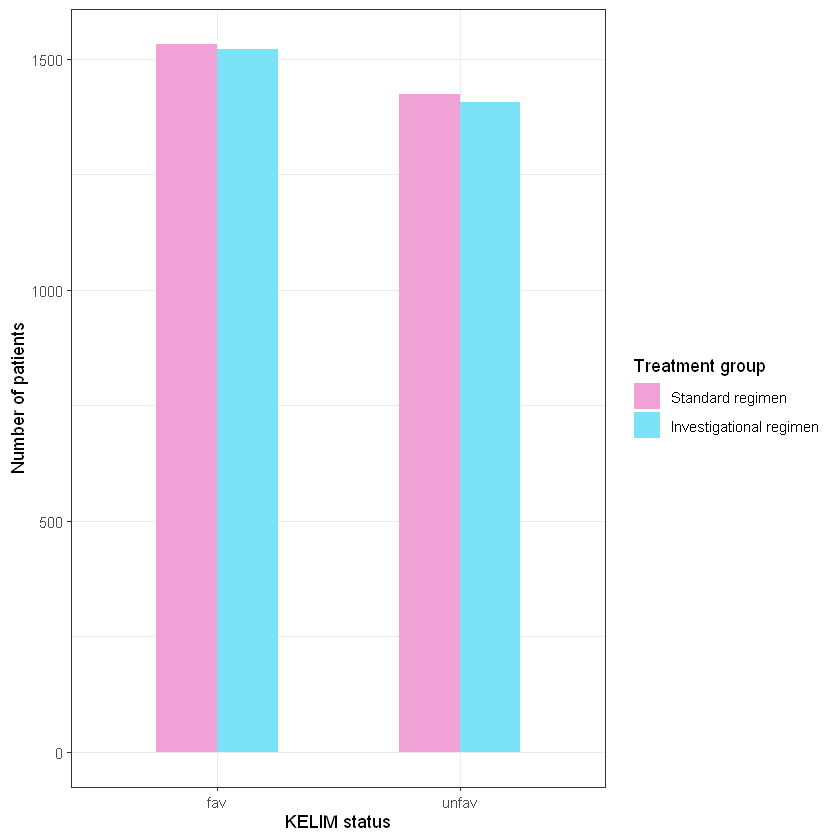

In [53]:
ggplot(data=as.data.frame(table(kelim_data$trt_bin,kelim_data$KELIM_score)), aes(x=Var2, y=Freq, group = Var1, fill = Var1)) + 
  geom_bar(stat = "identity", position = position_dodge(), width =  0.5)+
xlab("KELIM status") +
ylab("Number of patients")+
theme_bw()+
  scale_fill_manual(
    name = "Treatment group",
    values = c("0" = "#f0a1d5", "1" = "#7be2f7"),
    labels = c(
      "0" = "Standard regimen",
      "1" = "Investigational regimen"
    )) 




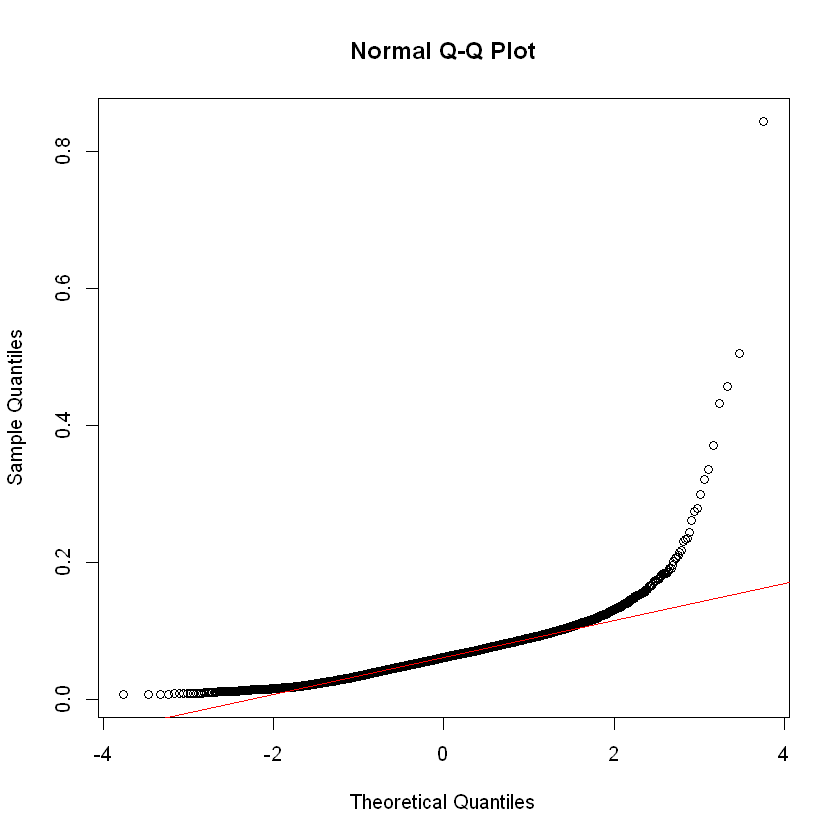

In [52]:
# Normality
qqnorm(kelim$KELIM_continuous)
qqline(kelim$KELIM_continuous, col="red")

In [ ]:
#Copula model
survcont_plackett_w<-MetaAnalyticSurvCont(
  data=kelim_data,
  true=pfs_time_d,
  trueind=pfs_statut,
  surrog=KELIM_continuous,
  trt=trt_bin,
  center=trialid_num,
  trial=trialid_num,
  patientid=id_num,
  copula="Plackett",
  adjustment="weighted"
)
print(paste0(c("Convergence:", survcont_plackett_w$nlm.output$code, "\nSummary:",print(survcont_plackett_w))))

In [ ]:
plot(survcont_plackett_w)